# **MÓDULO 20 - Projeto de Credit Score - Naive Bayes**


No módulo 17 vocês realizaram a primeira etapa do projeto de crédito de vocês.
Então fizeram o tratamendo dos dados, balancearam as classes, transformaram as variáveis categóricas e separam base de treino e teste.
Nessa aula aplicaremos o algoritmo de naive bayes a base de vocês afim de tentarmos trazer previsões do score de crédito.

**IMPORTANTE:** Não se esqueçam de ao enviar o código de vocês para os tutores, enviarem as bases, pois como cada um de vocês realizou as alterações de tratamento indidualmente o tutor precisa ter acesso aos seus dados individuais.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score

Durante a aula nossa variável a ser prevista (churn) continha apenas 2 categorias, a base de vocês contém mais. O Naive Bayes pode ser aplicado para problemas de classificação com múltiplas classes da mesma forma que para problemas de classificação binária. O Naive Bayes é um algoritmo de classificação probabilístico que calcula a probabilidade de uma amostra pertencer a cada classe e seleciona a classe com a maior probabilidade como a previsão final.
Em resumo, o Naive Bayes pode ser aplicado da mesma maneira para problemas de classificação com múltiplas classes, e os mesmos princípios se aplicam em termos de treinamento, avaliação e aplicação do modelo.

# 1) Comece carregando as bases de treino (X e y) e teste (X e y).
Verifique se o número de linhas condiz, se as variáveis estão corretas sendo apenas a de score para y e as demais nas bases de X e por último, se Y está balanceada no teste.

In [3]:
# Carregar as bases salvas no M17
X_train = pd.read_csv("X_train.csv")
y_train = pd.read_csv("y_train.csv").squeeze()
X_test = pd.read_csv("X_test.csv")
y_test = pd.read_csv("y_test.csv").squeeze()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train balanceada:", y_train.value_counts())

X_train: (270, 7)
X_test: (33, 7)
y_train balanceada: Credit Score_encoded
1    90
0    90
2    90
Name: count, dtype: int64


In [5]:
# Verificar y_test 
print("y_test distribuicao:")
print(y_test.value_counts())

# Verificar colunas de X
print("\nColunas de X_train:")
print(X_train.columns.tolist())

y_test distribuicao:
Credit Score_encoded
1    23
0     5
2     5
Name: count, dtype: int64

Colunas de X_train:
['Age', 'Income', 'Number of Children', 'Gender_encoded', 'Education_encoded', 'Marital Status_encoded', 'Home Ownership_encoded']


### Questão 1 - Verificacao das bases

**Linhas:**
- X_train: 270 linhas (90 por classe, balanceado com SMOTE)
- X_test: 33 linhas (distribuicao real)

**Variaveis em X:** Age, Income, Number of Children,
Gender_encoded, Education_encoded, Marital Status_encoded,
Home Ownership_encoded. Correto, sem a variavel target.

**y_train:** Perfeitamente balanceada com 90 registros por classe.

**y_test:** Desbalanceada (23 High, 5 Average, 5 Low),
o que e esperado pois a base de teste deve refletir
a realidade dos dados originais.

# 2) Aplique o algoritmo de Naive Bayes aos dados de treinamento.

In [8]:
# Treinar o modelo
modelo_nb = GaussianNB()
modelo_nb.fit(X_train, y_train)

print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


# 3) Faça a avaliação do modelo com os dados de treinamento.
Traga a acurácia, recall e plote a matriz de confusão. Não se esqueça de avaliar com suas palavras o desempenho do modelo, interpretando as métricas.

Dica: Para calcularmos o recall em classificação multi classe precisamos usar o atributo macro:
recall = recall_score(y_train, y_pred_train, average='macro')

Acuracia treino: 0.9778
Recall treino: 0.9778


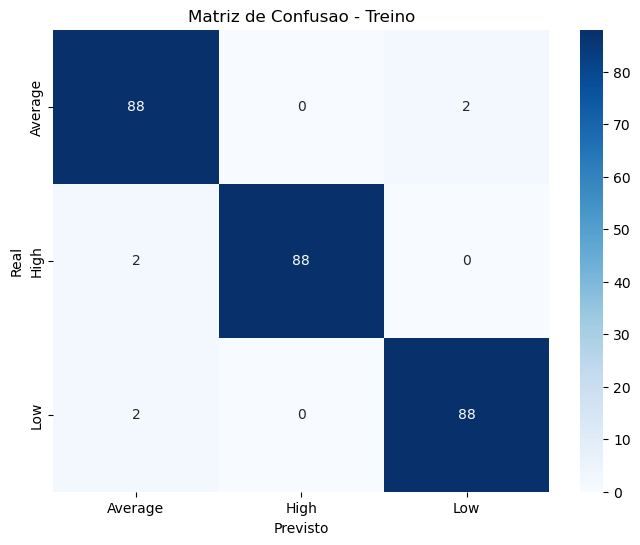

In [10]:
# Previsoes no treino
y_pred_train = modelo_nb.predict(X_train)

# Metricas
acuracia_train = accuracy_score(y_train, y_pred_train)
recall_train = recall_score(y_train, y_pred_train, average='macro')

print(f"Acuracia treino: {acuracia_train:.4f}")
print(f"Recall treino: {recall_train:.4f}")

# Matriz de confusao
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_train, y_pred_train)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Average', 'High', 'Low'],
            yticklabels=['Average', 'High', 'Low'])
plt.title('Matriz de Confusao - Treino')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.show()

### Questão 3 - Avaliacao no Treino

**Acuracia: 0.9778 (97.78%)**
**Recall: 0.9778 (97.78%)**

O modelo apresentou desempenho excelente na base de treino.

**Lendo a matriz de confusao:**
- Average: 88 acertos de 90 (2 confundidos com Low)
- High: 88 acertos de 90 (2 confundidos com Average)
- Low: 88 acertos de 90 (2 confundidos com Average)

O modelo errou apenas 6 casos de 270, distribuidos
de forma equilibrada entre as classes. Isso indica que
o Naive Bayes aprendeu bem os padroes das tres categorias
de score de credito na base de treino balanceada.

# 4) Aplique o modelo aos dados de teste e realize a avaliação dos resultados, da mesma forma que fez acima. Não se esqueça de avaliar com as suas palavras e comparar o desempenho da base treino com a teste.

Acuracia teste: 0.9394
Recall teste: 0.8667


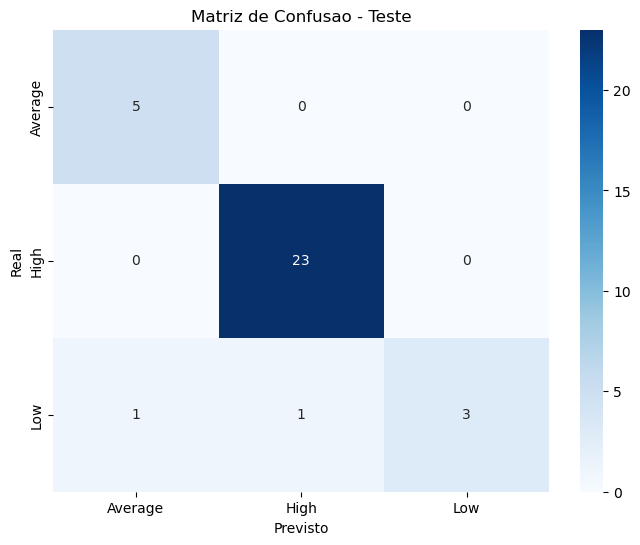

In [13]:
# Previsoes no teste
y_pred_test = modelo_nb.predict(X_test)

# Metricas
acuracia_test = accuracy_score(y_test, y_pred_test)
recall_test = recall_score(y_test, y_pred_test, average='macro')

print(f"Acuracia teste: {acuracia_test:.4f}")
print(f"Recall teste: {recall_test:.4f}")

# Matriz de confusao
plt.figure(figsize=(8, 6))
cm_test = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Average', 'High', 'Low'],
            yticklabels=['Average', 'High', 'Low'])
plt.title('Matriz de Confusao - Teste')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.show()

### Questão 4 - Avaliacao no Teste

**Acuracia: 0.9394 (93.94%)**
**Recall: 0.8667 (86.67%)**

**Lendo a matriz de confusao:**
- Average: 5 acertos de 5 (100% de aproveitamento)
- High: 23 acertos de 23 (100% de aproveitamento)
- Low: 3 acertos de 5 (2 erros, 1 confundido com Average
  e 1 com High)

A classe Low foi a unica com erros, o que faz sentido pois
e a classe com menos representantes na base de teste (apenas 5).

**Comparando treino e teste:**
- Acuracia: 97.78% no treino vs 93.94% no teste
- Recall: 97.78% no treino vs 86.67% no teste

A queda foi pequena e esperada. O modelo generalizou bem
para dados novos, sem sinais de overfitting grave.
O desempenho na base de teste e considerado muito bom,
especialmente levando em conta que a base de teste e pequena
(apenas 33 registros) e desbalanceada.

# 5) Descreva com suas palavras o projeto desenvolvido nessa atividade e qual o nosso objetivo principal ao aplicarmos o algoritmo de naive bayes a base de crédito.
Utilize pelo menos 4 linhas.

Dica: Caso você ainda esteja tendo dificuldade em visualizar a aplicação dos projetos e objetivo, consulte seus tutores!